In [1]:
import torch
from torch import nn,Tensor 
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from safeguard_llm.detectors.internal.linear_probe import LinearProbe

BATCH_SIZE = 32 

c:\Users\Ramneek\anaconda3\envs\safeguard_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("csv", data_files="jailbreak_generations_labeled.csv")
print(ds["train"]["labels"])

def label_to_tensor(example):
    example["labels"] = 1 if example["labels"].lower().strip() == "yes" else 0
    return example

ds = ds["train"].map(label_to_tensor)
ds = ds.train_test_split(test_size = 0.1)
train_dataloader = DataLoader(ds["train"], batch_size=2)
test_dataloader = DataLoader(ds["train"], batch_size=2)
for batch in train_dataloader:
    print(batch["labels"])  
    break

ds_yes = ds["train"].filter(lambda example: example["labels"] == "1")
ds_no = ds["train"].filter(lambda example: example["labels"] == "0")
print(ds_yes)
print(ds_no)

Column(['No', 'No', 'Yes', 'Yes', 'No', ...])
['0', '1']


Filter: 100%|██████████| 900/900 [00:00<00:00, 32164.36 examples/s]

Dataset({
    features: ['prompt', 'generation', 'labels'],
    num_rows: 200
})
Dataset({
    features: ['prompt', 'generation', 'labels'],
    num_rows: 700
})


In [3]:
from transformers import AutoModelForCausalLM,AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B", device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-1.7B", padding_side="left"
)
if torch.cuda.is_available():
    device = "cuda"
else: 
    device = "cpu"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights: 100%|██████████| 311/311 [00:14<00:00, 21.20it/s] 


In [5]:
import torch
from tqdm.auto import tqdm
import numpy as np 
from sklearn import metrics
import matplotlib.pyplot as plt  

def hook(module, input: Tensor, output: Tensor) -> None:
    global activation_cache 
    activation_cache = output[:, -1, :].detach().clone().to(device)

def train_model(layer,data):
    linear_probe_model = LinearProbe(in_dim=6144).to(device).bfloat16()

    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    optimizer = torch.optim.Adam(linear_probe_model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = torch.nn.BCEWithLogitsLoss()

    EPOCHS = 3
    linear_probe_model.train()
    for epoch in range(EPOCHS): 
        pbar = tqdm(data, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=True)
        
        for batch in pbar:
            inputs = batch["prompt"]
            labels = torch.tensor(list(map(int, batch["labels"]))).to(device).bfloat16()
            tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            optimizer.zero_grad() 
            loss = loss_fn(scores.squeeze(-1), labels)
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    forward_hook.remove()
    return linear_probe_model

def eval_accuracy(linear_probe_model, layer,data,threshold):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    tp_list = []
    fp_list = []
    for batch in pbar:
        inputs = batch["prompt"]
        labels = torch.tensor(list(map(int, batch["labels"]))).to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model.predict(activation_cache,threshold=threshold)
            scores = scores.squeeze(-1)
            tp += torch.sum(torch.logical_and(scores == 1 ,labels == 1))
            tn += torch.sum(torch.logical_and(scores == 0,labels == 0))
            fp += torch.sum(torch.logical_and(scores == 1,labels == 0))
            fn += torch.sum(torch.logical_and(scores == 0,labels == 1))
    tp_list.append(tp)
    fp_list.append(fp)
    print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    print(fp)
    print(tn)
    print(fn)
    accuracy = (tp + tn) /( tp + fp + tn + fn)
    print(accuracy)
    forward_hook.remove()

def roc(linear_probe_model, layer,data):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    scores_full = []
    labels_full = []
    for batch in pbar:
        inputs = batch["prompt"]
        labels = torch.tensor(list(map(int, batch["labels"]))).to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            scores_full.extend(scores.squeeze(-1).float().cpu())
            labels_full.extend(labels.float().cpu())
    fpr, tpr, thresholds = metrics.roc_curve(labels_full,scores_full)
    auroc_score = metrics.roc_auc_score(labels_full,scores_full)
    roc_auc = metrics.auc(fpr, tpr)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                    name='example estimator')
    display.plot()
    plt.show()
    print("Auroc score: ", auroc_score)
    forward_hook.remove()

In [ ]:
linear_probe_model = train_model(27,train_dataloader)

Epoch 3/3: 100%|██████████| 450/450 [02:37<00:00,  2.86it/s, loss=0.0000]


In [9]:
torch.save(linear_probe_model.state_dict(), "model_linear_jailbreak_qwen3_1_7b.pt")

100%|██████████| 450/450 [02:38<00:00,  2.84it/s]


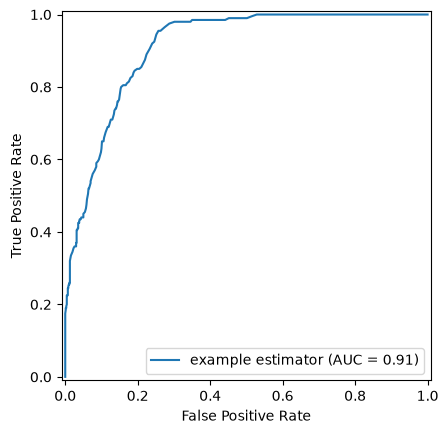

Auroc score:  0.9103607142857143


In [6]:
roc(linear_probe_model,27,test_dataloader)

In [10]:
eval_accuracy(linear_probe_model, 27, test_dataloader, threshold = 0.5)

100%|██████████| 450/450 [02:36<00:00,  2.88it/s]


TP: 2, FP: 0, TN: 700, FN: 198
tensor(0, device='cuda:0')
tensor(700, device='cuda:0')
tensor(198, device='cuda:0')
tensor(0.7800, device='cuda:0')
